# Final Wedding Venue Style Classifier — Commented Version with XAI

Ce notebook entraîne un modèle de classification d’images pour reconnaître le style d’un lieu de mariage.

L’objectif est de classer une image dans une des 4 catégories :

- `luxury_ballroom`
- `rustic_wood`
- `natural_outdoor`
- `tent_elegant`

Ensuite, le notebook propose une recommandation de décoration adaptée au style prédit.

## Améliorations principales

- Utilisation d’un modèle EfficientNet-B3 pré-entraîné
- Augmentation de données pour améliorer la généralisation
- Entraînement en deux phases
- Gestion du déséquilibre des classes avec des poids
- MixUp pour rendre le modèle plus robuste
- Sauvegarde du meilleur modèle
- Courbes d’entraînement
- Matrice de confusion
- Prédiction avec Test-Time Augmentation
- Ajout d’une partie Explainable AI avec Grad-CAM

## Dataset attendu

Le notebook attend un fichier `.zip` contenant ces dossiers :

```text
luxury_ballroom/
rustic_wood/
natural_outdoor/
tent_elegant/
```


## 0. Check GPU

Cette partie vérifie si Colab utilise bien un GPU. C’est important parce que l’entraînement d’un modèle deep learning est beaucoup plus rapide sur GPU.


In [1]:
# Cette cellule vérifie si le GPU est disponible pour accélérer l'entraînement.

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 1. Upload and unzip dataset

Ici, on importe le fichier `.zip` du dataset, on l’extrait, puis on cherche automatiquement les 4 dossiers de classes attendus.


In [2]:
# Cette cellule importe le dataset zip, l'extrait, puis localise le dossier contenant les classes.

from google.colab import files
import zipfile
import shutil
import os
from pathlib import Path

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

extract_dir = Path("/content/final_wedding_dataset")

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

expected = {"luxury_ballroom", "rustic_wood", "natural_outdoor", "tent_elegant"}
DATASET_DIR = None

for root, dirs, file_names in os.walk(extract_dir):
    if expected.issubset(set(dirs)):
        DATASET_DIR = Path(root)
        break

if DATASET_DIR is None:
    raise ValueError("Could not find the expected class folders.")

print("Dataset directory:", DATASET_DIR)
print("Classes found:", sorted(os.listdir(DATASET_DIR)))

Saving final_wedding_dataset_4classes_RUSTIC_BOOSTED.zip to final_wedding_dataset_4classes_RUSTIC_BOOSTED.zip
Dataset directory: /content/final_wedding_dataset/final_wedding_dataset_4classes_RUSTIC_BOOSTED
Classes found: ['README.md', 'luxury_ballroom', 'metadata.csv', 'natural_outdoor', 'rustic_wood', 'tent_elegant']


## 2. Dataset check

Cette partie vérifie que les images sont lisibles, compte le nombre total d’images et affiche la répartition par classe.


In [3]:
# Cette cellule parcourt toutes les images pour vérifier qu'elles sont valides et compter les classes.

from PIL import Image
import pandas as pd

valid_exts = [".jpg", ".jpeg", ".png"]
rows = []
broken = []

for class_folder in sorted(DATASET_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    for file in class_folder.iterdir():
        if file.suffix.lower() not in valid_exts:
            continue
        try:
            img = Image.open(file).convert("RGB")
            rows.append({
                "path": str(file),
                "class": class_folder.name,
                "width": img.size[0],
                "height": img.size[1]
            })
        except Exception as e:
            broken.append((str(file), str(e)))

df = pd.DataFrame(rows)

print("Total valid images:", len(df))
print()
print("Class distribution:")
print(df["class"].value_counts())

if broken:
    print("\nBroken images:")
    for item in broken:
        print(item)
else:
    print("\nNo broken images found.")

Total valid images: 70

Class distribution:
class
luxury_ballroom    21
tent_elegant       20
rustic_wood        16
natural_outdoor    13
Name: count, dtype: int64

No broken images found.


## 3. Visualize samples

Ici, on affiche quelques exemples d’images par classe pour vérifier visuellement que le dataset est cohérent.


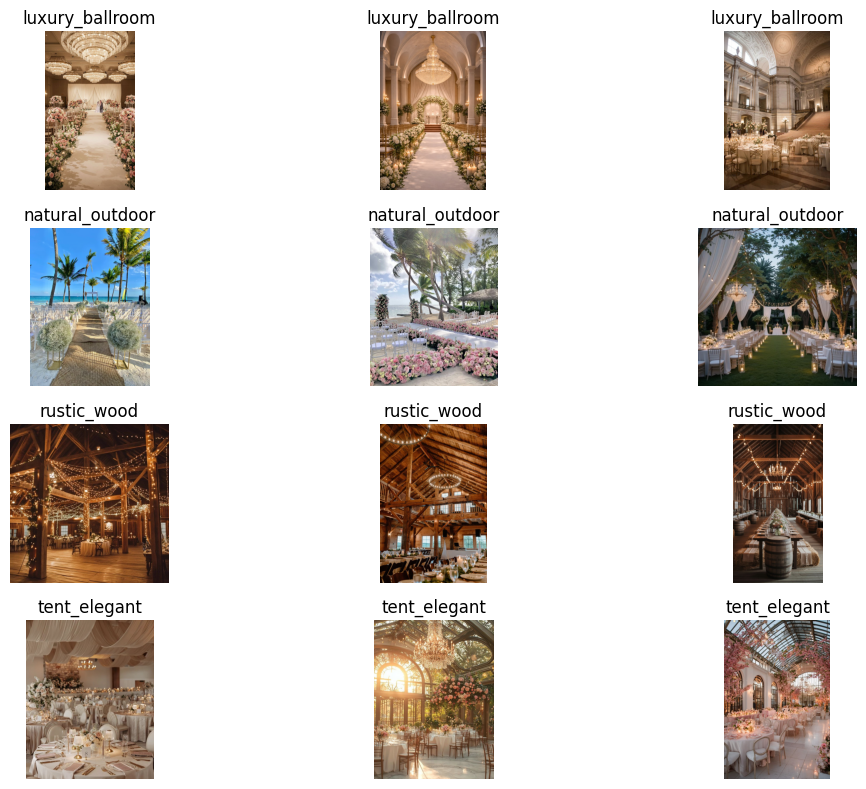

In [4]:
# Cette cellule affiche quelques images de chaque classe pour contrôler visuellement le dataset.

import matplotlib.pyplot as plt
import random

class_folders = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])

plt.figure(figsize=(12, 8))
idx = 1

for folder in class_folders:
    imgs = list(folder.glob("*.jpg"))
    samples = random.sample(imgs, min(3, len(imgs)))

    for img_path in samples:
        img = Image.open(img_path).convert("RGB")
        plt.subplot(len(class_folders), 3, idx)
        plt.imshow(img)
        plt.title(folder.name)
        plt.axis("off")
        idx += 1

plt.tight_layout()
plt.show()

## 4. Imports and reproducibility

Cette partie importe les bibliothèques principales et fixe une seed pour rendre les résultats plus stables d’une exécution à l’autre.


In [5]:
# Imports principaux + fixation de la seed pour avoir des résultats plus reproductibles.

import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 5. Transforms

Les transformations préparent les images avant de les envoyer au modèle. Pour l’entraînement, on ajoute de l’augmentation de données. Pour la validation, on garde un prétraitement plus simple.


In [6]:
# Définition de la taille d'image, du batch size et des transformations train/validation.

IMG_SIZE = 300
BATCH_SIZE = 8

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.30, contrast=0.30, saturation=0.30),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 6. Stratified train/validation split

Ici, le dataset est séparé en données d’entraînement et de validation en gardant la même proportion de classes dans les deux parties.


In [7]:
# Séparation stratifiée : garde une distribution équilibrée des classes entre train et validation.

base_dataset = datasets.ImageFolder(DATASET_DIR)
class_names = base_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(base_dataset))

targets = [label for _, label in base_dataset.samples]
indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.25,
    stratify=targets,
    random_state=SEED
)

train_full = datasets.ImageFolder(DATASET_DIR, transform=train_transforms)
val_full = datasets.ImageFolder(DATASET_DIR, transform=val_transforms)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("\nValidation distribution:")
val_labels = [targets[i] for i in val_indices]
for i, name in enumerate(class_names):
    print(name, ":", val_labels.count(i))

Classes: ['luxury_ballroom', 'natural_outdoor', 'rustic_wood', 'tent_elegant']
Number of classes: 4
Total images: 70
Train images: 52
Validation images: 18

Validation distribution:
luxury_ballroom : 6
natural_outdoor : 3
rustic_wood : 4
tent_elegant : 5


## 7. Class weights

Cette partie calcule des poids pour compenser un éventuel déséquilibre entre les classes. Une classe avec moins d’images peut ainsi avoir plus d’importance dans la loss.


In [8]:
# Calcul des poids de classes pour réduire l'effet d'un dataset déséquilibré.

train_labels = np.array([targets[i] for i in train_indices])

weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)

class_weights = torch.tensor(weights_np, dtype=torch.float32).to(device)

print("Class weights:")
for cls, w in zip(class_names, weights_np):
    print(f"{cls}: {w:.3f}")

Class weights:
luxury_ballroom: 0.867
natural_outdoor: 1.300
rustic_wood: 1.083
tent_elegant: 0.867


## 8. Visual check of augmented images

On affiche des images après augmentation pour vérifier que les transformations ne déforment pas trop les données.


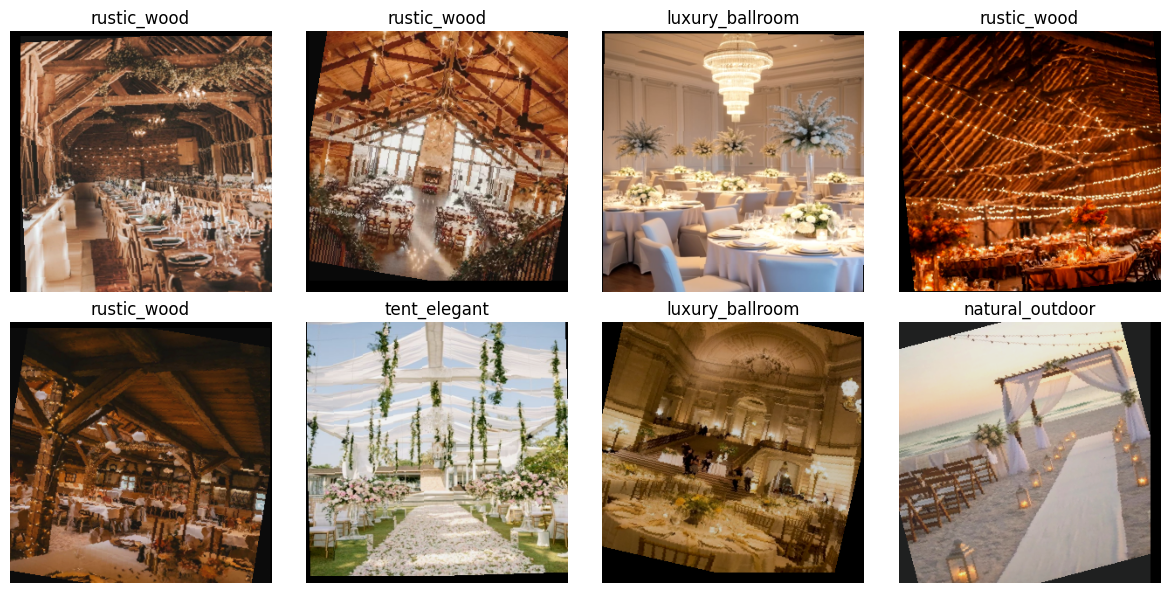

In [9]:
# Affichage d'images augmentées pour vérifier que les transformations restent réalistes.

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor.cpu() * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Build EfficientNet-B3 with better classifier head

On charge EfficientNet-B3 pré-entraîné sur ImageNet, puis on remplace sa dernière couche pour l’adapter à nos 4 styles de lieux de mariage.


In [10]:
# Chargement d'EfficientNet-B3 pré-entraîné et remplacement de la tête de classification.

model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.40),
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.SiLU(),
    nn.Dropout(p=0.30),
    nn.Linear(256, num_classes)
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 137MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1536, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): SiLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=4, bias=True)
)


## 10. MixUp functions

MixUp mélange deux images et leurs labels pendant l’entraînement. Cela aide le modèle à mieux généraliser, surtout avec un petit dataset.


In [11]:
# Fonctions MixUp : mélange d'images pour améliorer la généralisation du modèle.

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(device)

    mixed_x = lam * x + (1 - lam) * x[rand_index]
    y_a = y
    y_b = y[rand_index]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

## 11. Training and evaluation functions

Ces fonctions regroupent la logique d’entraînement et d’évaluation pour éviter de répéter le même code à chaque epoch.


In [12]:
# Fonctions réutilisables pour entraîner une epoch et évaluer le modèle.

def train_one_epoch(model, loader, optimizer, criterion, use_mixup=True):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        if use_mixup:
            mixed_images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # For training accuracy, use original labels only as an approximate indicator
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

## 12. Phase 1 — Train classifier only

Pendant cette première phase, on bloque EfficientNet et on entraîne seulement la nouvelle tête de classification. Cela évite d’abîmer les poids pré-entraînés trop tôt.


In [13]:
# Phase 1 : seul le classifieur final apprend, le backbone EfficientNet reste gelé.

# Freeze full model
for param in model.parameters():
    param.requires_grad = False

# Train only classifier
for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

PHASE1_EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Starting Phase 1: classifier only")

for epoch in range(PHASE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, use_mixup=True
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Phase 1 - Epoch [{epoch+1}/{PHASE1_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

Starting Phase 1: classifier only
Phase 1 - Epoch [1/5]
Train Loss: 1.3246 | Train Acc: 0.2885
Val Loss:   1.3278 | Val Acc:   0.3889
--------------------------------------------------
Phase 1 - Epoch [2/5]
Train Loss: 1.0385 | Train Acc: 0.4615
Val Loss:   1.2131 | Val Acc:   0.5556
--------------------------------------------------
Phase 1 - Epoch [3/5]
Train Loss: 0.7582 | Train Acc: 0.6154
Val Loss:   1.1219 | Val Acc:   0.6111
--------------------------------------------------
Phase 1 - Epoch [4/5]
Train Loss: 0.7450 | Train Acc: 0.4231
Val Loss:   1.1310 | Val Acc:   0.6111
--------------------------------------------------
Phase 1 - Epoch [5/5]
Train Loss: 0.8087 | Train Acc: 0.4808
Val Loss:   1.1817 | Val Acc:   0.5556
--------------------------------------------------


## 13. Phase 2 — Fine-tune last EfficientNet blocks

Pendant cette deuxième phase, on débloque les derniers blocs du modèle pour l’adapter plus finement aux images de lieux de mariage.


In [14]:
# Phase 2 : on fine-tune les derniers blocs d'EfficientNet + le classifieur.

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last EfficientNet blocks
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

PHASE2_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

best_val_acc = 0.0
epochs_without_improvement = 0
best_model_path = "/content/best_wedding_model_upgraded.pth"

print("Starting Phase 2: fine-tuning last blocks")

for epoch in range(PHASE2_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, use_mixup=True
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Phase 2 - Epoch [{epoch+1}/{PHASE2_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE
        }, best_model_path)

        print(f"✅ New best model saved: val acc = {best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", best_val_acc)
print("Best model:", best_model_path)

Starting Phase 2: fine-tuning last blocks
Phase 2 - Epoch [1/15]
Train Loss: 0.8033 | Train Acc: 0.7692
Val Loss:   1.0918 | Val Acc:   0.7778
--------------------------------------------------
✅ New best model saved: val acc = 0.7778
Phase 2 - Epoch [2/15]
Train Loss: 0.7279 | Train Acc: 0.6538
Val Loss:   1.1168 | Val Acc:   0.7778
--------------------------------------------------
Phase 2 - Epoch [3/15]
Train Loss: 0.5882 | Train Acc: 0.8462
Val Loss:   1.0711 | Val Acc:   0.7778
--------------------------------------------------
Phase 2 - Epoch [4/15]
Train Loss: 0.8197 | Train Acc: 0.5192
Val Loss:   1.0482 | Val Acc:   0.7778
--------------------------------------------------
Phase 2 - Epoch [5/15]
Train Loss: 0.6257 | Train Acc: 0.7500
Val Loss:   1.0040 | Val Acc:   0.8333
--------------------------------------------------
✅ New best model saved: val acc = 0.8333
Phase 2 - Epoch [6/15]
Train Loss: 0.6380 | Train Acc: 0.4615
Val Loss:   1.0284 | Val Acc:   0.8333
---------------

## 14. Plot and save training curves

Cette partie trace les courbes de loss et d’accuracy afin de voir si le modèle apprend correctement ou s’il overfit.


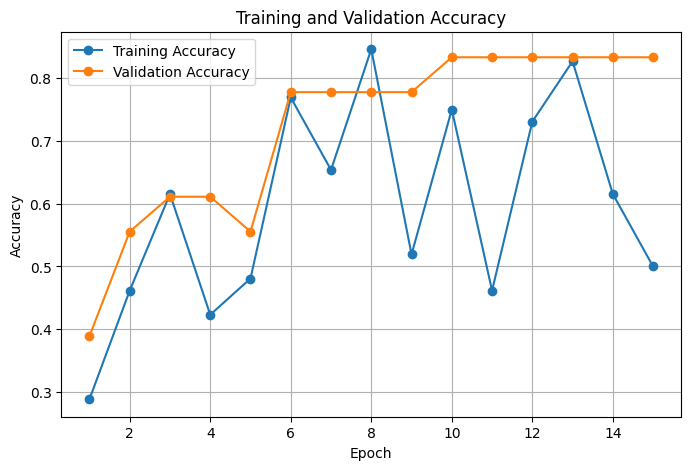

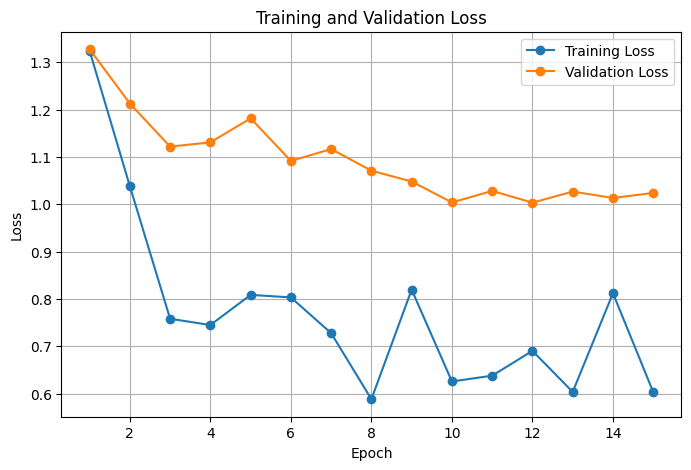

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Affichage et sauvegarde des courbes d'accuracy et de loss.

epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("/content/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("/content/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

files.download("/content/accuracy_curve.png")
files.download("/content/loss_curve.png")

## 15. Load best model and evaluate

Ici, on recharge le meilleur modèle sauvegardé pendant l’entraînement, puis on l’évalue sur la validation.


In [16]:
# Rechargement du meilleur modèle sauvegardé et évaluation finale.

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
class_names = checkpoint["class_names"]

val_loss, val_acc, preds, true_labels = evaluate(model, val_loader, criterion)

print("Best model validation accuracy:", round(val_acc * 100, 2), "%")
print()
print(classification_report(true_labels, preds, target_names=class_names, zero_division=0))

Best model validation accuracy: 83.33 %

                 precision    recall  f1-score   support

luxury_ballroom       0.80      0.67      0.73         6
natural_outdoor       1.00      0.67      0.80         3
    rustic_wood       0.80      1.00      0.89         4
   tent_elegant       0.83      1.00      0.91         5

       accuracy                           0.83        18
      macro avg       0.86      0.83      0.83        18
   weighted avg       0.84      0.83      0.83        18



## 16. Confusion matrix

La matrice de confusion permet de voir quelles classes sont bien reconnues et quelles classes sont confondues entre elles.


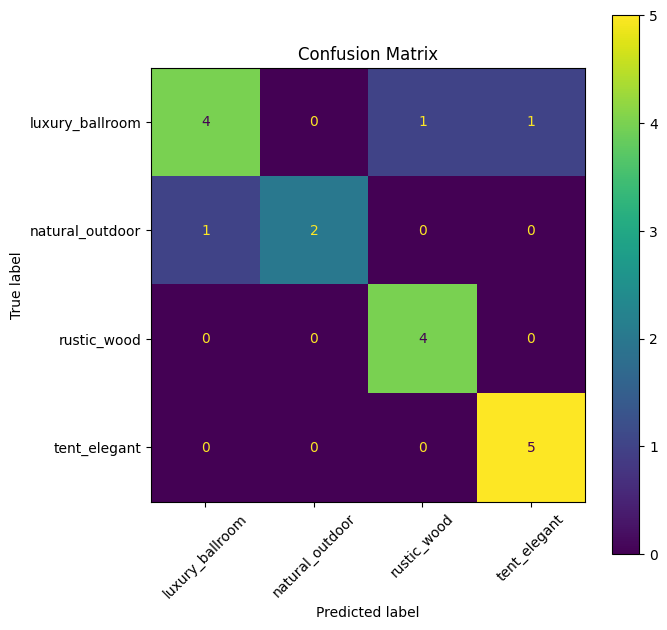

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Affichage de la matrice de confusion pour analyser les erreurs entre classes.

cm = confusion_matrix(true_labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

files.download("/content/confusion_matrix.png")

## 17. Prediction with Test-Time Augmentation

Cette partie permet de tester une image. Le modèle fait plusieurs prédictions avec de petites variations de l’image, puis moyenne les résultats pour obtenir une prédiction plus robuste.


Saving Elegant Modern Wedding Hall – Beige & White Floral Arrangements & Minimalist Luxury Decor.webp to Elegant Modern Wedding Hall – Beige & White Floral Arrangements & Minimalist Luxury Decor.webp
Predicted class: luxury_ballroom
Confidence: 84.5 %

luxury_ballroom: 84.50%
rustic_wood: 5.89%
tent_elegant: 5.79%
natural_outdoor: 3.82%


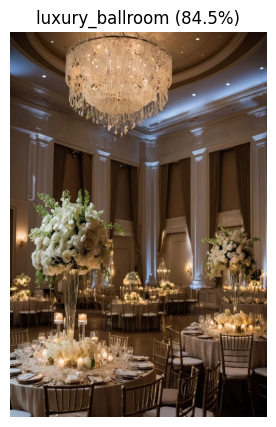

In [18]:
# Prédiction sur une nouvelle image avec Test-Time Augmentation.

CONFIDENCE_THRESHOLD = 0.55

tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_with_tta(image_path, n_augments=7):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    probs_list = []

    with torch.no_grad():
        for _ in range(n_augments):
            tensor = tta_transform(img).unsqueeze(0).to(device)
            probs = torch.softmax(model(tensor), dim=1)[0]
            probs_list.append(probs)

    avg_probs = torch.stack(probs_list).mean(dim=0)
    pred_idx = avg_probs.argmax().item()

    predicted_class = class_names[pred_idx]
    confidence = avg_probs[pred_idx].item()

    all_probs = sorted(
        zip(class_names, avg_probs.cpu().numpy()),
        key=lambda x: x[1],
        reverse=True
    )

    return predicted_class, confidence, all_probs


uploaded_test = files.upload()
test_image_path = list(uploaded_test.keys())[0]

predicted_class, confidence, all_probs = predict_with_tta(test_image_path, n_augments=7)

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

if confidence < CONFIDENCE_THRESHOLD:
    print(f"⚠️ Low confidence ({confidence*100:.1f}%). The image may be mixed or outside the known styles.")

print()
for cls, prob in all_probs:
    print(f"{cls}: {prob * 100:.2f}%")

img = Image.open(test_image_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence*100:.1f}%)")
plt.axis("off")
plt.show()

## 18. Decoration recommender with confidence check

Après la prédiction du style, cette partie génère des recommandations de décoration adaptées à la classe prédite.


In [19]:
# Génération de recommandations déco selon le style prédit et la confiance du modèle.

recommendations = {
    "luxury_ballroom": {
        "explanation": "Elegant indoor venue with chandeliers, gold/white tones, or a ballroom/palace atmosphere.",
        "colors": ["gold", "ivory", "champagne", "white"],
        "decor": [
            "Use crystal chandeliers",
            "Add tall floral centerpieces",
            "Use gold chairs and elegant tableware",
            "Use candles and reflective surfaces",
            "Keep the layout symmetrical and premium"
        ]
    },
    "rustic_wood": {
        "explanation": "Wooden or barn-like venue with beams, warm lighting, and natural materials.",
        "colors": ["wood brown", "cream", "olive green", "terracotta"],
        "decor": [
            "Use wooden tables and cross-back chairs",
            "Add warm string lights",
            "Use greenery and simple flowers",
            "Add candles for a cozy mood",
            "Use linen, wood, and stone textures"
        ]
    },
    "natural_outdoor": {
        "explanation": "Outdoor venue with trees, beach, garden, mountain, or open-air natural scenery.",
        "colors": ["green", "ivory", "soft pink", "sand beige"],
        "decor": [
            "Use floral arches with natural greenery",
            "Keep decoration light and airy",
            "Use lanterns or fairy lights",
            "Use flowers matching the natural setting",
            "Avoid overloading the scenery"
        ]
    },
    "tent_elegant": {
        "explanation": "Elegant structured venue with drapes, glass/orangery features, or fabric-based decor.",
        "colors": ["white", "champagne", "soft gold", "blush pink"],
        "decor": [
            "Use ceiling drapes and hanging greenery",
            "Add chandeliers or warm hanging lights",
            "Use soft floral arrangements",
            "Highlight the tent/glass structure",
            "Use clean table settings with elegant lighting"
        ]
    }
}

def generate_recommendation(style, confidence):
    if confidence < CONFIDENCE_THRESHOLD:
        print("Recommendation is shown, but confidence is low. Use it carefully.")
        print()

    rec = recommendations[style]

    print("AI Decoration Recommendation")
    print("=" * 40)
    print("Predicted style:", style)
    print("Confidence:", round(confidence * 100, 2), "%")
    print()
    print("Why?")
    print(rec["explanation"])
    print()
    print("Suggested colors:")
    for c in rec["colors"]:
        print("-", c)
    print()
    print("Decoration ideas:")
    for idea in rec["decor"]:
        print("-", idea)

generate_recommendation(predicted_class, confidence)

AI Decoration Recommendation
Predicted style: luxury_ballroom
Confidence: 84.5 %

Why?
Elegant indoor venue with chandeliers, gold/white tones, or a ballroom/palace atmosphere.

Suggested colors:
- gold
- ivory
- champagne
- white

Decoration ideas:
- Use crystal chandeliers
- Add tall floral centerpieces
- Use gold chairs and elegant tableware
- Use candles and reflective surfaces
- Keep the layout symmetrical and premium


## 19. Explainable AI — Grad-CAM

Cette partie ajoute une explication visuelle à la prédiction du modèle.

Grad-CAM affiche les zones de l’image qui ont le plus influencé la décision du modèle. Les zones chaudes indiquent les parties les plus importantes pour la classe prédite.


In [20]:
# Installation de la bibliothèque utilisée pour Grad-CAM.
# À exécuter une seule fois dans Colab.
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f05ce3d165bbb392864f8dca9d9f62a9584024f133875ed813a8729deffd4af5
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [21]:
# Imports nécessaires pour générer une carte Grad-CAM.
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def explain_with_gradcam(model, image_path, transform, class_names):
    """
    Génère une explication visuelle Grad-CAM pour une image.

    Le modèle prédit d'abord la classe de l'image.
    Ensuite, Grad-CAM montre quelles zones de l'image ont influencé cette prédiction.
    """
    model.eval()

    # Charger l'image et appliquer le même prétraitement que pour la validation.
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Faire une prédiction classique.
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)[0]
    predicted_class = probs.argmax().item()
    confidence = probs[predicted_class].item()

    # Pour EfficientNet, on utilise le dernier bloc de features comme couche cible.
    target_layers = [model.features[-1]]

    # Générer la carte Grad-CAM pour la classe prédite.
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Préparer l'image originale pour superposer la heatmap.
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Afficher image originale + explication Grad-CAM.
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    plt.title(f"Grad-CAM: {class_names[predicted_class]} ({confidence*100:.1f}%)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return class_names[predicted_class], confidence


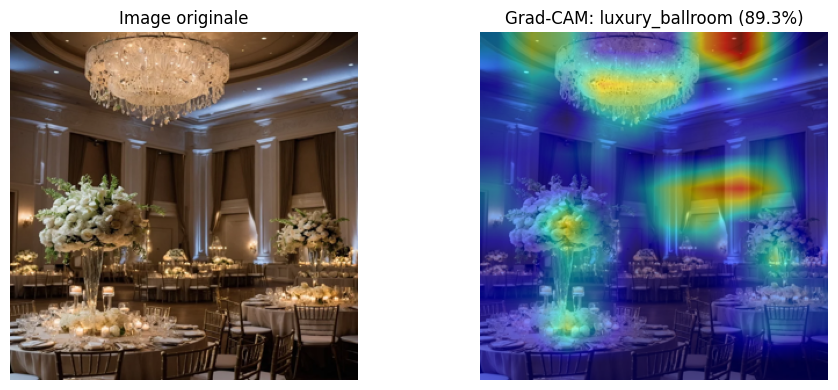

('luxury_ballroom', 0.8925102353096008)

In [22]:
# Exemple d'utilisation de Grad-CAM.
# Si tu as déjà uploadé une image dans la partie prédiction, on réutilise test_image_path.
# Sinon, remplace test_image_path par le chemin de ton image.

explain_with_gradcam(
    model=model,
    image_path=test_image_path,
    transform=val_transforms,
    class_names=class_names
)


## 20. Download trained model

Cette cellule télécharge le meilleur modèle entraîné afin de pouvoir le réutiliser plus tard sans refaire l’entraînement.


In [23]:
# Téléchargement du modèle entraîné.

files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Presentation note

Cette partie donne une explication simple que tu peux utiliser dans ta présentation pour justifier les améliorations apportées au notebook.
